In [21]:
import os
import sys
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

from statsmodels.tsa.stattools import pacf
from statsmodels.graphics.tsaplots import plot_pacf

from sklearn.preprocessing import MinMaxScaler

sys.path.insert(0, os.path.abspath(".."))

In [22]:
DATA_PATH = "../data/processed/dataset_CI_RE_2024_2025_cleaned.csv"

OUTPUT_DIR = "../data/processed/normalized"
os.makedirs(OUTPUT_DIR, exist_ok=True)

TRAIN_RATIO = 0.8

MAX_LAG = 48

CI_COL = "carbon_intensity"
RE_COL = "renewable_percentage"

TARGET_COLS = [
    CI_COL,
    RE_COL
]

print("Configuration ready.")
print(f"Data       : {DATA_PATH}")
print(f"Train ratio: {TRAIN_RATIO}")
print(f"Max lag    : {MAX_LAG}")

Configuration ready.
Data       : ../data/processed/dataset_CI_RE_2024_2025_cleaned.csv
Train ratio: 0.8
Max lag    : 48


In [23]:
df = pd.read_csv(DATA_PATH)

df["datetime"] = pd.to_datetime(
    df["datetime"],
    utc=True
)

df = (
    df
    .sort_values("datetime")
    .set_index("datetime")
)

print("Dataset loaded.")
print(f"Shape: {df.shape}")

display(df.head())

Dataset loaded.
Shape: (17544, 2)


,carbon_intensity,renewable_percentage
datetime,,
2024-01-01 00:00:00+00:00,584.32,16.06
2024-01-01 01:00:00+00:00,580.70,16.19
2024-01-01 02:00:00+00:00,575.88,16.56
2024-01-01 03:00:00+00:00,577.33,16.41
2024-01-01 04:00:00+00:00,577.58,16.37


In [24]:
print("=== DATA VALIDATION ===")

print("\nMissing values:")
print(df.isna().sum())

print("\nDuplicate timestamps:")
print(df.index.duplicated().sum())

print("\nTime range:")
print(f"{df.index.min()} → {df.index.max()}")

print("\nData types:")
print(df.dtypes)

=== DATA VALIDATION ===

Missing values:
carbon_intensity        0
renewable_percentage    0
dtype: int64

Duplicate timestamps:
0

Time range:
2024-01-01 00:00:00+00:00 → 2025-12-31 23:00:00+00:00

Data types:
carbon_intensity        float64
renewable_percentage    float64
dtype: object


In [25]:
time_diff = df.index.to_series().diff().dropna()

print("\n=== TIME INTERVAL ===")
print(time_diff.value_counts().head())


=== TIME INTERVAL ===
datetime
0 days 01:00:00    17543
Name: count, dtype: int64


In [26]:
df_features = df.copy()

hour = df_features.index.hour
day_of_week = df_features.index.dayofweek
month = df_features.index.month

df_features["hour_sin"] = np.sin(
    2 * np.pi * hour / 24
)

df_features["hour_cos"] = np.cos(
    2 * np.pi * hour / 24
)

df_features["dow_sin"] = np.sin(
    2 * np.pi * day_of_week / 7
)

df_features["dow_cos"] = np.cos(
    2 * np.pi * day_of_week / 7
)

df_features["month_sin"] = np.sin(
    2 * np.pi * (month - 1) / 12
)

df_features["month_cos"] = np.cos(
    2 * np.pi * (month - 1) / 12
)

print("Time features added.")
print(df_features.columns.tolist())

Time features added.
['carbon_intensity', 'renewable_percentage', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']


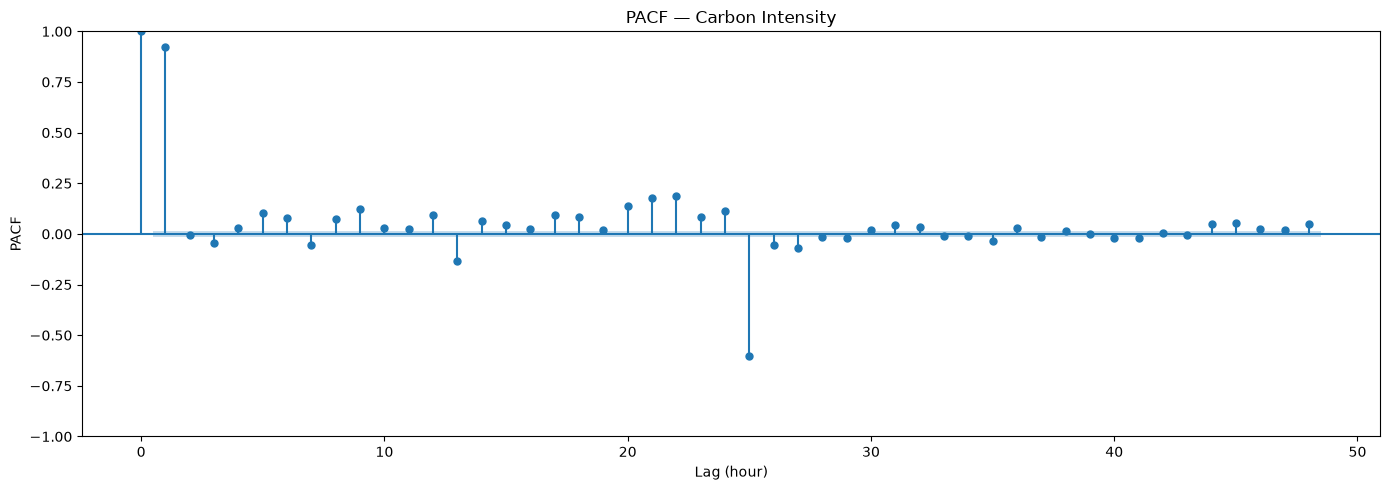

In [27]:
ci_series = df[CI_COL].dropna()

fig, ax = plt.subplots(figsize=(14, 5))
plot_pacf(
    ci_series,
    lags=MAX_LAG,
    method="ywm",
    ax=ax
)

ax.set_title("PACF — Carbon Intensity")
ax.set_xlabel("Lag (hour)")
ax.set_ylabel("PACF")

plt.tight_layout()
plt.show()

In [28]:
pacf_ci = pacf(
    ci_series,
    nlags=MAX_LAG,
    method="ywm"
)

ci_threshold = 1.96 / np.sqrt(len(ci_series))

significant_lags_ci = [
    lag
    for lag in range(1, MAX_LAG + 1)
    if abs(pacf_ci[lag]) > ci_threshold
]

print("=== CI PACF ===")
print(f"Threshold : ±{ci_threshold:.6f}")
print(f"Significant lags: {significant_lags_ci}")

=== CI PACF ===
Threshold : ±0.014798
Significant lags: [1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 29, 30, 31, 32, 35, 36, 40, 41, 44, 45, 46, 47, 48]


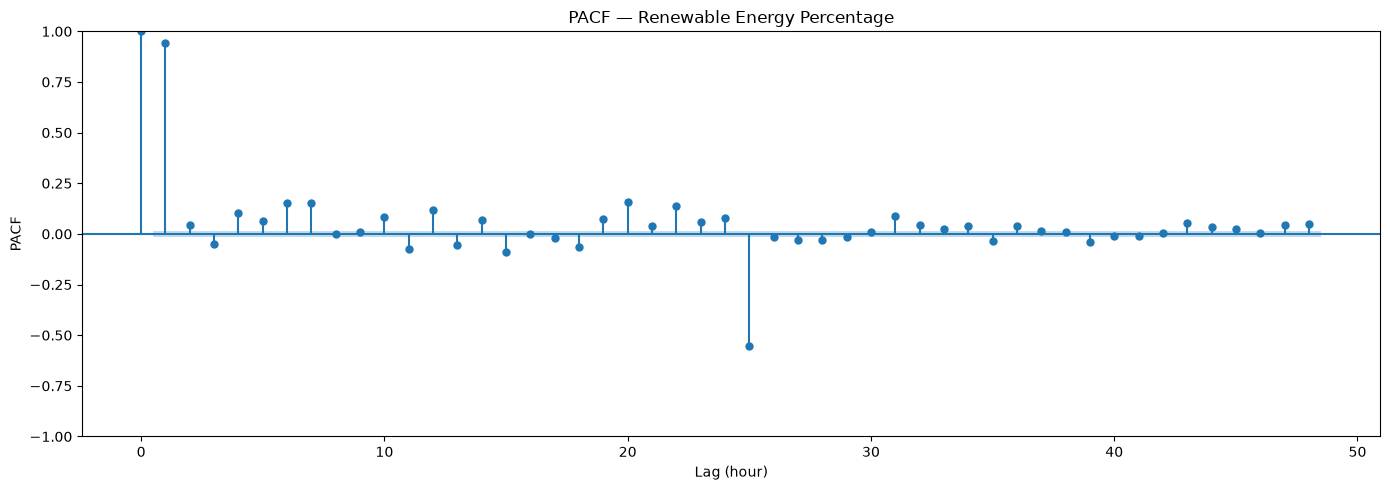

In [29]:
re_series = df[RE_COL].dropna()

fig, ax = plt.subplots(figsize=(14, 5))

plot_pacf(
    re_series,
    lags=MAX_LAG,
    method="ywm",
    ax=ax
)

ax.set_title("PACF — Renewable Energy Percentage")
ax.set_xlabel("Lag (hour)")
ax.set_ylabel("PACF")

plt.tight_layout()
plt.show()

In [30]:
pacf_re = pacf(
    re_series,
    nlags=MAX_LAG,
    method="ywm"
)

re_threshold = 1.96 / np.sqrt(len(re_series))

significant_lags_re = [
    lag
    for lag in range(1, MAX_LAG + 1)
    if abs(pacf_re[lag]) > re_threshold
]

print("=== RE PACF ===")
print(f"Threshold : ±{re_threshold:.6f}")
print(f"Significant lags: {significant_lags_re}")

=== RE PACF ===
Threshold : ±0.014798
Significant lags: [1, 2, 3, 4, 5, 6, 7, 10, 11, 12, 13, 14, 15, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 31, 32, 33, 34, 35, 36, 39, 43, 44, 45, 47, 48]


In [31]:
for lag in significant_lags_ci:
    df_features[f"CI_lag_{lag}"] = df_features[CI_COL].shift(lag)

for lag in significant_lags_re:
    df_features[f"RE_lag_{lag}"] = df_features[RE_COL].shift(lag)

print("Lag features added.")

print("\nCI lag features:")
print([
    c for c in df_features.columns
    if c.startswith("CI_lag_")
])

print("\nRE lag features:")
print([
    c for c in df_features.columns
    if c.startswith("RE_lag_")
])

Lag features added.

CI lag features:
['CI_lag_1', 'CI_lag_3', 'CI_lag_4', 'CI_lag_5', 'CI_lag_6', 'CI_lag_7', 'CI_lag_8', 'CI_lag_9', 'CI_lag_10', 'CI_lag_11', 'CI_lag_12', 'CI_lag_13', 'CI_lag_14', 'CI_lag_15', 'CI_lag_16', 'CI_lag_17', 'CI_lag_18', 'CI_lag_19', 'CI_lag_20', 'CI_lag_21', 'CI_lag_22', 'CI_lag_23', 'CI_lag_24', 'CI_lag_25', 'CI_lag_26', 'CI_lag_27', 'CI_lag_29', 'CI_lag_30', 'CI_lag_31', 'CI_lag_32', 'CI_lag_35', 'CI_lag_36', 'CI_lag_40', 'CI_lag_41', 'CI_lag_44', 'CI_lag_45', 'CI_lag_46', 'CI_lag_47', 'CI_lag_48']

RE lag features:
['RE_lag_1', 'RE_lag_2', 'RE_lag_3', 'RE_lag_4', 'RE_lag_5', 'RE_lag_6', 'RE_lag_7', 'RE_lag_10', 'RE_lag_11', 'RE_lag_12', 'RE_lag_13', 'RE_lag_14', 'RE_lag_15', 'RE_lag_17', 'RE_lag_18', 'RE_lag_19', 'RE_lag_20', 'RE_lag_21', 'RE_lag_22', 'RE_lag_23', 'RE_lag_24', 'RE_lag_25', 'RE_lag_26', 'RE_lag_27', 'RE_lag_28', 'RE_lag_31', 'RE_lag_32', 'RE_lag_33', 'RE_lag_34', 'RE_lag_35', 'RE_lag_36', 'RE_lag_39', 'RE_lag_43', 'RE_lag_44', 'RE_lag_

In [32]:
before = len(df_features)

df_features = df_features.dropna()

after = len(df_features)

print(f"Rows before dropna : {before}")
print(f"Rows after dropna  : {after}")
print(f"Rows removed       : {before - after}")

Rows before dropna : 17544
Rows after dropna  : 17496
Rows removed       : 48


In [33]:
print("\nRemaining missing values:")
print(df_features.isna().sum())


Remaining missing values:
carbon_intensity        0
renewable_percentage    0
hour_sin                0
hour_cos                0
dow_sin                 0
                       ..
RE_lag_43               0
RE_lag_44               0
RE_lag_45               0
RE_lag_47               0
RE_lag_48               0
Length: 84, dtype: int64


In [34]:
time_cols = [
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos"
]

lag_ci_cols = [
    c for c in df_features.columns
    if c.startswith("CI_lag_")
]

lag_re_cols = [
    c for c in df_features.columns
    if c.startswith("RE_lag_")
]

In [35]:
feature_cols_uni_ci = (
    [CI_COL]
    + lag_ci_cols
    + time_cols
)

target_cols_uni_ci = [CI_COL]

In [36]:
feature_cols_uni_re = (
    [RE_COL]
    + lag_re_cols
    + time_cols
)

target_cols_uni_re = [RE_COL]

In [37]:
feature_cols_multi = (
    [CI_COL, RE_COL]
    + lag_ci_cols
    + lag_re_cols
    + time_cols
)

target_cols_multi = [
    CI_COL,
    RE_COL
]

In [38]:
print("=== FEATURE CONFIGURATION ===")

print(f"\nUnivariate CI ({len(feature_cols_uni_ci)} features)")
print(feature_cols_uni_ci)

print(f"\nUnivariate RE ({len(feature_cols_uni_re)} features)")
print(feature_cols_uni_re)

print(f"\nMultivariate ({len(feature_cols_multi)} features)")
print(feature_cols_multi)

=== FEATURE CONFIGURATION ===

Univariate CI (46 features)
['carbon_intensity', 'CI_lag_1', 'CI_lag_3', 'CI_lag_4', 'CI_lag_5', 'CI_lag_6', 'CI_lag_7', 'CI_lag_8', 'CI_lag_9', 'CI_lag_10', 'CI_lag_11', 'CI_lag_12', 'CI_lag_13', 'CI_lag_14', 'CI_lag_15', 'CI_lag_16', 'CI_lag_17', 'CI_lag_18', 'CI_lag_19', 'CI_lag_20', 'CI_lag_21', 'CI_lag_22', 'CI_lag_23', 'CI_lag_24', 'CI_lag_25', 'CI_lag_26', 'CI_lag_27', 'CI_lag_29', 'CI_lag_30', 'CI_lag_31', 'CI_lag_32', 'CI_lag_35', 'CI_lag_36', 'CI_lag_40', 'CI_lag_41', 'CI_lag_44', 'CI_lag_45', 'CI_lag_46', 'CI_lag_47', 'CI_lag_48', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']

Univariate RE (44 features)
['renewable_percentage', 'RE_lag_1', 'RE_lag_2', 'RE_lag_3', 'RE_lag_4', 'RE_lag_5', 'RE_lag_6', 'RE_lag_7', 'RE_lag_10', 'RE_lag_11', 'RE_lag_12', 'RE_lag_13', 'RE_lag_14', 'RE_lag_15', 'RE_lag_17', 'RE_lag_18', 'RE_lag_19', 'RE_lag_20', 'RE_lag_21', 'RE_lag_22', 'RE_lag_23', 'RE_lag_24', 'RE_lag_25', 'RE_lag_26', 'RE

In [39]:
train_size = int(len(df_features) * TRAIN_RATIO)

train_df = df_features.iloc[:train_size].copy()
test_df = df_features.iloc[train_size:].copy()

print("=== TEMPORAL SPLIT ===")

print(f"Train size: {len(train_df)}")
print(f"Test size : {len(test_df)}")

print(
    f"\nTrain: {train_df.index.min()} → {train_df.index.max()}"
)

print(
    f"Test : {test_df.index.min()} → {test_df.index.max()}"
)

=== TEMPORAL SPLIT ===
Train size: 13996
Test size : 3500

Train: 2024-01-03 00:00:00+00:00 → 2025-08-08 03:00:00+00:00
Test : 2025-08-08 04:00:00+00:00 → 2025-12-31 23:00:00+00:00


In [40]:
scaler_multi = MinMaxScaler()

scaler_multi.fit(
    train_df[feature_cols_multi]
)

train_scaled_multi = pd.DataFrame(
    scaler_multi.transform(
        train_df[feature_cols_multi]
    ),
    columns=feature_cols_multi,
    index=train_df.index
)

test_scaled_multi = pd.DataFrame(
    scaler_multi.transform(
        test_df[feature_cols_multi]
    ),
    columns=feature_cols_multi,
    index=test_df.index
)

In [41]:
print("=== TRAIN NORMALIZATION ===")

print(
    train_scaled_multi.describe()
    .loc[["min", "max"]]
    .T
)

=== TRAIN NORMALIZATION ===
                      min  max
carbon_intensity      0.0  1.0
renewable_percentage  0.0  1.0
CI_lag_1              0.0  1.0
CI_lag_3              0.0  1.0
CI_lag_4              0.0  1.0
...                   ...  ...
hour_cos              0.0  1.0
dow_sin               0.0  1.0
dow_cos               0.0  1.0
month_sin             0.0  1.0
month_cos             0.0  1.0

[84 rows x 2 columns]


In [42]:
print("\n=== TEST NORMALIZATION ===")

print(
    test_scaled_multi.describe()
    .loc[["min", "max"]]
    .T
)


=== TEST NORMALIZATION ===
                           min       max
carbon_intensity      0.087687  0.976306
renewable_percentage  0.018705  0.951079
CI_lag_1              0.087687  0.976306
CI_lag_3              0.087687  0.976306
CI_lag_4              0.087687  0.976306
...                        ...       ...
hour_cos              0.000000  1.000000
dow_sin               0.000000  1.000000
dow_cos               0.000000  1.000000
month_sin             0.000000  0.250000
month_cos             0.066987  0.933013

[84 rows x 2 columns]


In [43]:
train_scaled_multi.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "train_multivariate_normalized.csv"
    )
)

test_scaled_multi.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "test_multivariate_normalized.csv"
    )
)

print("Normalized datasets saved.")

Normalized datasets saved.


In [44]:
df_features.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "dataset_feature_engineered.csv"
    )
)

print("Feature-engineered dataset saved.")

Feature-engineered dataset saved.


In [45]:
import joblib

joblib.dump(
    scaler_multi,
    os.path.join(
        OUTPUT_DIR,
        "scaler_multivariate.pkl"
    )
)

print("Scaler saved.")

Scaler saved.


In [46]:
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=train_df.index,
        y=train_df[CI_COL],
        name="Original CI"
    )
)

fig.add_trace(
    go.Scatter(
        x=train_scaled_multi.index,
        y=train_scaled_multi[CI_COL],
        name="Normalized CI"
    )
)

fig.update_layout(
    title="Carbon Intensity — Original vs Normalized",
    xaxis_title="Datetime",
    yaxis_title="Value"
)

fig.show()

In [47]:
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=train_df.index,
        y=train_df[RE_COL],
        name="Original RE"
    )
)

fig.add_trace(
    go.Scatter(
        x=train_scaled_multi.index,
        y=train_scaled_multi[RE_COL],
        name="Normalized RE"
    )
)

fig.update_layout(
    title="Renewable Energy Percentage — Original vs Normalized",
    xaxis_title="Datetime",
    yaxis_title="Value"
)

fig.show()